In [1]:
import json
from collections import Counter
from matplotlib import pyplot as plt

In [2]:
with open('1-raw/mcqtimes.json', 'r') as f:
    mcqtimes = json.load(f)


In [3]:
len(mcqtimes)

6170

In [4]:
mcqtimes[0]

{'domain': 'URDU LITERATURE MISC – متفرق اردو ادب',
 'question': 'وے صورتیں الہی کس دیس بستیاں ہیں – اب دیکھنے کو جن کے آنکھیں ترستیاں ہیں – یہ کس شاعر کا شعر ہے؟',
 'options': {'A': 'میرتقی میر',
  'B': 'محمد رفیع سودا',
  'C': 'خواجہ حیدر بخش علی آتش',
  'D': 'مصحفی'},
 'correct_option': 'محمد رفیع سودا',
 'correct_index': 1,
 'page': 1,
 'source_url': 'https://mcqtimes.com/category/urdu/',
 'level': ''}

In [5]:
# unique subdomains in native_mcqs
subdomains = set(mcq['domain'] for mcq in mcqtimes)
subdomains

{'(URDU LITERATURE) اردو ادب',
 'URDU LITERATURE MISC – متفرق اردو ادب',
 'ادبی اصطلاحات (LITERARY TERMS)',
 'اردو ادب بیسویں صدی میں (بالخصوص شاعری)',
 'اردو افسانے کی روایت',
 'اردو تنقید و تحقیق کی روایت',
 'اردو زبان کا آغاز و ارتقاء',
 'اردو محاورے (URDU IDIOMS)',
 'اردو کا ابتدائی زمانہ (آغاز سے قطب شاہی عہد تک)',
 'اردو کا ابتدائی زمانہ (فورٹ ولیم کالج اور آتش و ناسخ کا عہد)',
 'اردو کا ابتدائی زمانہ (قطب شاہی عہد سے لے کر ایہام گوئی تحریک تک)',
 'اردو کا ابتدائی زمانہ (میروسودا کے عہد سے لے کر آٹھارویں صدی کے اختتام تک)',
 'تاریخ اردو ادب'}

In [6]:
subdomain_mapping = {
    "(URDU LITERATURE) اردو ادب": "urdu literature",
    "URDU LITERATURE MISC – متفرق اردو ادب": "urdu literature",
    "ادبی اصطلاحات (LITERARY TERMS)": "urdu literature",
    "اردو ادب بیسویں صدی میں (بالخصوص شاعری)": "urdu literature",
    "اردو افسانے کی روایت": "urdu literature",
    "اردو تنقید و تحقیق کی روایت": "urdu literature",
    "اردو کا ابتدائی زمانہ (آغاز سے قطب شاہی عہد تک)": "urdu literature",
    "اردو کا ابتدائی زمانہ (فورٹ ولیم کالج اور آتش و ناسخ کا عہد)": "urdu literature",
    "اردو کا ابتدائی زمانہ (قطب شاہی عہد سے لے کر ایہام گوئی تحریک تک)": "urdu literature",
    "اردو کا ابتدائی زمانہ (میروسودا کے عہد سے لے کر آٹھارویں صدی کے اختتام تک)": "urdu literature",
    "تاریخ اردو ادب": "urdu literature",
    "اردو زبان کا آغاز و ارتقاء": "urdu language",
    "اردو محاورے (URDU IDIOMS)": "urdu grammar"
}

mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the std_subdomain key in native_data with mapped subdomain
for mcq in mcqtimes:
    original_subdomain = mcq['domain']
    mapped_subdomain = subdomain_mapping.get(original_subdomain, original_subdomain)
    mcq['subdomain'] = mapped_subdomain

In [7]:
# unique subdomains in native_mcqs
subdomains = set(mcq['subdomain'] for mcq in mcqtimes)
subdomains

{'urdu grammar', 'urdu language', 'urdu literature'}

In [8]:
# add source key with the values as mcqtimes
for item in mcqtimes:
    item['source'] = 'mcqtimes'
    item.pop("page")

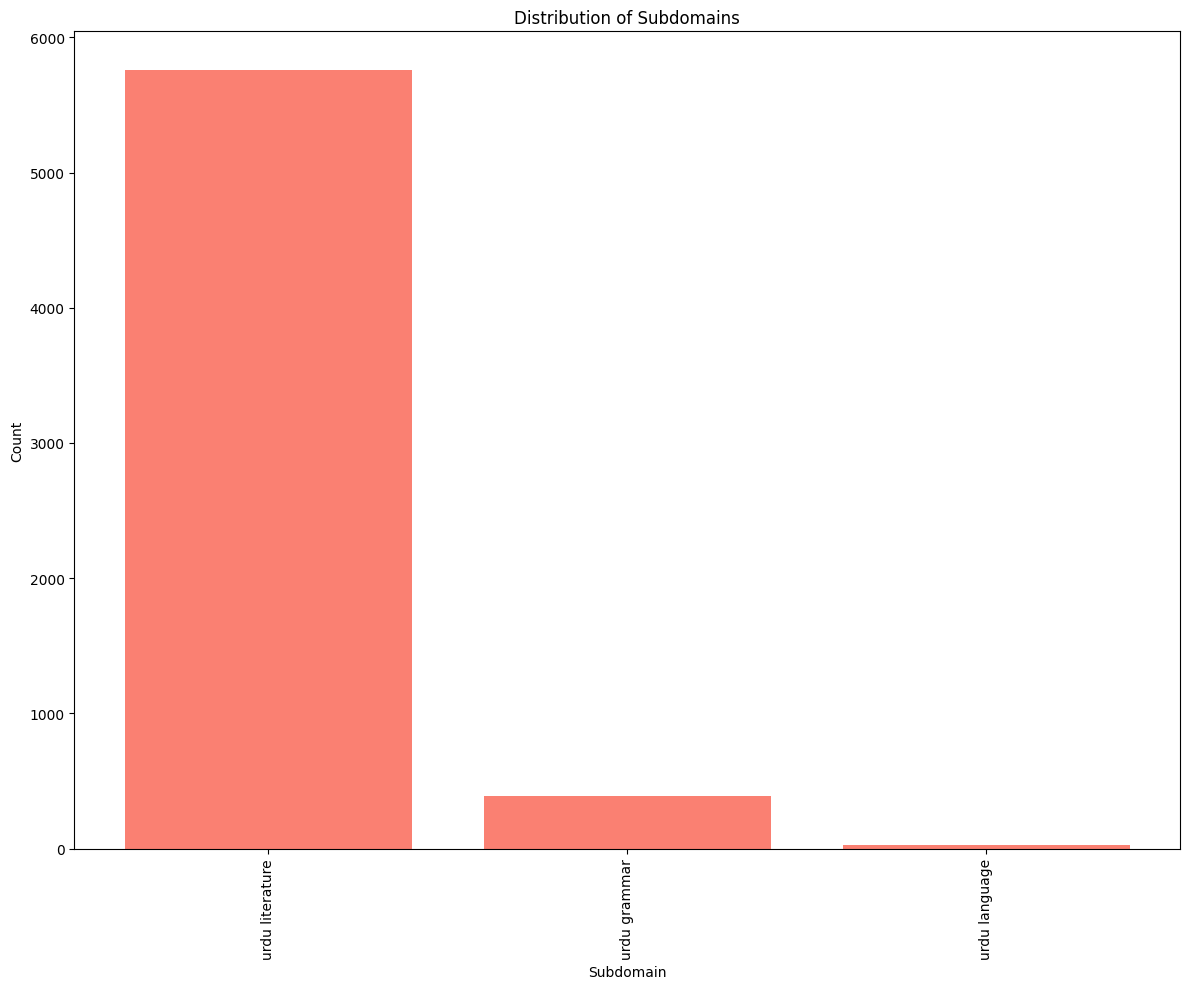

In [9]:
subdomains = [item['subdomain'] for item in mcqtimes]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
mcqtimes[0]

{'domain': 'URDU LITERATURE MISC – متفرق اردو ادب',
 'question': 'وے صورتیں الہی کس دیس بستیاں ہیں – اب دیکھنے کو جن کے آنکھیں ترستیاں ہیں – یہ کس شاعر کا شعر ہے؟',
 'options': {'A': 'میرتقی میر',
  'B': 'محمد رفیع سودا',
  'C': 'خواجہ حیدر بخش علی آتش',
  'D': 'مصحفی'},
 'correct_option': 'محمد رفیع سودا',
 'correct_index': 1,
 'source_url': 'https://mcqtimes.com/category/urdu/',
 'level': '',
 'subdomain': 'urdu literature',
 'source': 'mcqtimes'}

In [11]:
with open('2-processed/mcqtimes.json', 'w', encoding='utf-8') as f:
    json.dump(mcqtimes, f, ensure_ascii=False, indent=4)